<a href="https://colab.research.google.com/github/Artem1965/DS23_Module4_Assignment/blob/main/DS23_Session30_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIU DS23 · Session 30 · Data Cleaning
**Module 4: Data & Feature Engineering · Session 3 of 6**

Two sessions ago we found where the data lives. Today we discover it lies:
missing values, outliers, and decisions you must not fake. This session births
the two most important threads of the module, **Data Leakage** and the **Pipeline**.

**How this notebook works (in class):**
1. Run *Setup* once at the start.
2. Demo sections are run live by the instructor.
3. Practice sections are yours: Part A, then Part B, then the stretch.
4. Full solutions are at the very end.

## 0 · Setup
Installs, mounts Drive, loads the raw products and orders tables, and freezes the SEED.

In [ ]:
# Setup 1/2: installs and imports
!pip install -q missingno scikit-learn pandas

import numpy as np, pandas as pd, missingno as msno
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)

from google.colab import drive
drive.mount("/content/drive")
#DATA_PATH = "/content/drive/MyDrive/DS23/olist/"
DATA_PATH = "/content/drive/My Drive/BAR ILAN/Modules/Module 1_  AI Foundations and Ethics/2. Python and SQL for Data Science/Data/Brazilian E-Commerce Public Dataset by Olist/"


Mounted at /content/drive


In [ ]:
# Setup 2/2: load the RAW tables, no cleaning yet. This is the point.
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
orders   = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
reviews  = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")

print("products:", products.shape)
print("orders  :", orders.shape)
print("items   :", items.shape)
print("reviews :", reviews.shape)


products: (32951, 9)
orders  : (99441, 8)
items   : (112650, 7)
reviews : (99224, 7)


---
# Macro-cycle 1 · Understand the gap before you fill it

## Demo A · Profiling missingness in products
Before fixing anything, we map the gaps at three levels: counts, percentages,
and pattern. The pattern level is where the story hides.

In [ ]:
# Level 1 and 2: count and percentage of missing values per column
miss = pd.DataFrame({
    "n_missing": products.isna().sum(),
    "pct_missing": (products.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
miss[miss["n_missing"] > 0]


,n_missing,pct_missing
product_category_name,610,1.85
product_description_lenght,610,1.85
product_name_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_height_cm,2,0.01
product_length_cm,2,0.01
product_width_cm,2,0.01


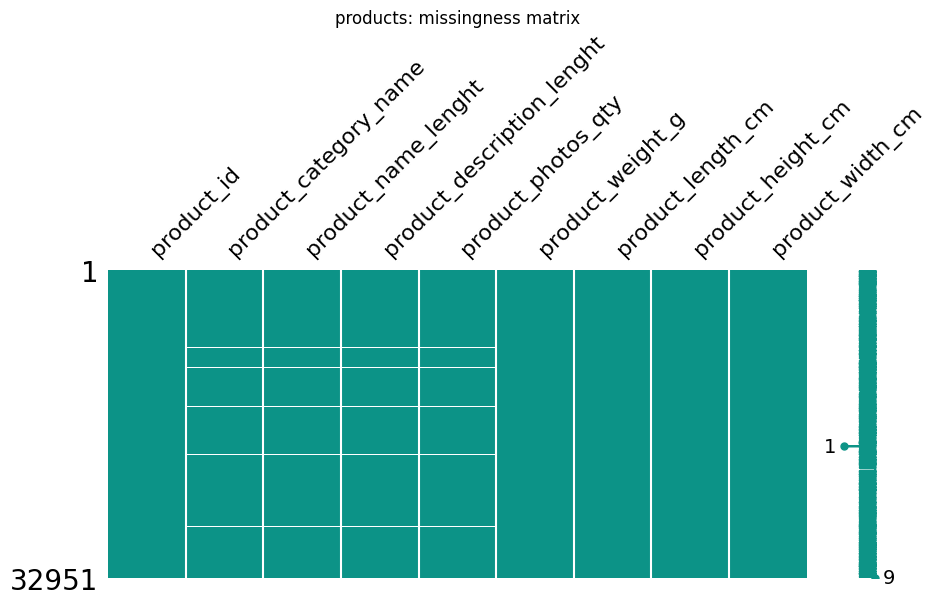

In [ ]:
# Level 3: the pattern. A missingno matrix reveals co-missingness.
# White stripes that line up across columns = those columns go missing together.
msno.matrix(products, figsize=(10, 4), color=(0.05, 0.58, 0.53))
plt.title("products: missingness matrix")
plt.show()


In [ ]:
# Confirm co-missingness numerically: do the product dimensions vanish together?
dim_cols = ["product_weight_g", "product_length_cm",
            "product_height_cm", "product_width_cm"]
both_missing = products[dim_cols].isna().all(axis=1).sum()
any_missing  = products[dim_cols].isna().any(axis=1).sum()
print(f"rows where ALL four dimensions are missing: {both_missing}")
print(f"rows where ANY dimension is missing       : {any_missing}")
print("If these are equal, the dimensions are missing as a block: a MAR clue.")


rows where ALL four dimensions are missing: 2
rows where ANY dimension is missing       : 2
If these are equal, the dimensions are missing as a block: a MAR clue.


## Cycle 1 takeaway
The gaps are not random noise. The dimensions disappear as a block, which points
to MAR (missing depends on something observed, like a product type never measured
in the warehouse). That classification decides the fix.

---
## Practice 1
**Part A**, then **Part B**, then the stretch.

### Part A · Profile a new table
Profile missingness in the `reviews` table (counts, percentages, and a matrix).
Notice that the comment column is missing in most rows. Classify each column's
missingness as MCAR, MAR, or MNAR, and justify in one line.

                         n_missing  pct_missing
review_comment_title         87656        88.34
review_comment_message       58247        58.70
review_id                        0         0.00
review_score                     0         0.00
order_id                         0         0.00
review_creation_date             0         0.00
review_answer_timestamp          0         0.00


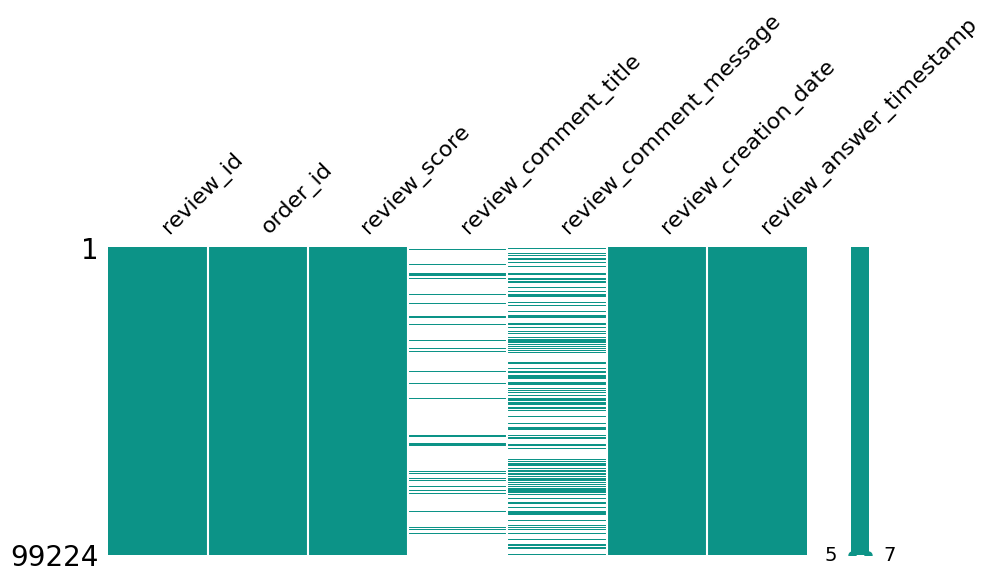

In [ ]:
# Part A: your profiling here
# TODO: counts, percentages, msno.matrix on reviews
rev_miss = pd.DataFrame({
    "n_missing": reviews.isna().sum(),
    "pct_missing": (reviews.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
print(rev_miss)
msno.matrix(reviews, figsize=(10, 4), color=(0.05, 0.58, 0.53))
plt.show()


### Part B
**B1.** Does the missingness in the comment column depend on the review score?
Compare the missing rate separately for positive and negative reviews.

**B2.** Given what you found, what is the correct classification for this gap?

In [ ]:
# B1: missing rate of the comment, split by review score
# TODO: compute reviews["review_comment_message"].isna() rate for score<=2 vs score>=4
neg = reviews["review_score"] <= 2
pos = reviews["review_score"] >= 4
rate_neg = reviews.loc[neg, "review_comment_message"].isna().mean()
rate_pos = reviews.loc[pos, "review_comment_message"].isna().mean()
print(f"comment missing rate, negative reviews: {rate_neg:.3f}")
print(f"comment missing rate, positive reviews: {rate_pos:.3f}")



comment missing rate, negative reviews: 0.253
comment missing rate, positive reviews: 0.653


In [ ]:
# B2: write your classification and justification as a comment
# The comment missingness is ... (MCAR / MAR / MNAR) because ...


### Stretch
If the very absence of a comment predicts the score, then "comment is missing"
could itself be a feature. This is a first hint of *missingness as signal*.

In [ ]:
# Stretch: build a binary 'comment_missing' column and check its correlation with a low score
# TODO


---
# Macro-cycle 2 · Impute, Leakage, and the Pipeline

## Demo A · Data Leakage, live, in two numbers
The most important idea in the module. We impute the WRONG way (before the split)
and the RIGHT way (inside a Pipeline), and read the gap in the CV scores.

In [ ]:
# Build a small modeling table: predict a negative review from product + item features.
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# One row per order item, joined to product features and a negative-review label
df = (items
      .merge(products, on="product_id", how="left")
      .merge(reviews[["order_id", "review_score"]], on="order_id", how="left"))
df = df.dropna(subset=["review_score"]).copy()
df["neg_review"] = (df["review_score"] <= 2).astype(int)

num_cols = ["price", "freight_value", "product_weight_g",
            "product_length_cm", "product_height_cm", "product_width_cm"]
cat_cols = ["product_category_name"]
X = df[num_cols + cat_cols]
y = df["neg_review"]
print("modeling table:", X.shape, "| positive rate:", round(y.mean(), 3))


modeling table: (112372, 7) | positive rate: 0.161


In [ ]:
X_leaked = X.copy()
for c in num_cols:
    X_leaked[c] = X_leaked[c].fillna(X_leaked[c].median())   # median from the WHOLE set
X_leaked[cat_cols[0]] = X_leaked[cat_cols[0]].fillna("missing")
X_leaked = pd.get_dummies(X_leaked, columns=cat_cols)

leaked_score = cross_val_score(
    LogisticRegression(max_iter=1000), X_leaked, y, cv=5, scoring="roc_auc"
).mean()
print(f"LEAKED cv roc_auc  : {leaked_score:.4f}  (imputation saw the test folds)")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LEAKED cv roc_auc  : 0.5558  (imputation saw the test folds)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# THE RIGHT WAY: imputation lives inside a Pipeline, fit per fold on train only.
numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
pre = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols),
])
clean_pipe = Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])

clean_score = cross_val_score(clean_pipe, X, y, cv=5, scoring="roc_auc").mean()
print(f"CLEAN  cv roc_auc  : {clean_score:.4f}  (no leakage)")
print(f"the leakage gap    : {leaked_score - clean_score:+.4f}")


CLEAN  cv roc_auc  : 0.5571  (no leakage)
the leakage gap    : -0.0013


## Demo B · Which imputation wins? Measure it.
Same pipeline, four imputation strategies, one honest table. Often the differences
are smaller than expected, and that itself is the lesson.

In [ ]:
# Swap only the numeric imputer; keep everything else identical. Measure each.
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

def score_with(numeric_imputer, add_indicator=False):
    num = Pipeline([
        ("impute", numeric_imputer),
        ("scale", StandardScaler()),
    ])
    if add_indicator:
        num.set_params(impute__add_indicator=True)
    ct = ColumnTransformer([("num", num, num_cols), ("cat", categorical, cat_cols)])
    pipe = Pipeline([("pre", ct), ("model", LogisticRegression(max_iter=1000))])
    return cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()

results = {
    "median":            score_with(SimpleImputer(strategy="median")),
    "median + indicator":score_with(SimpleImputer(strategy="median"), add_indicator=True),
    "KNN":               score_with(KNNImputer(n_neighbors=5)),
    "iterative (MICE)":  score_with(IterativeImputer(random_state=SEED, max_iter=10)),
}
for name, sc in results.items():
    print(f"{name:20s} cv roc_auc: {sc:.4f}")


median               cv roc_auc: 0.5571
median + indicator   cv roc_auc: 0.5567
KNN                  cv roc_auc: 0.5572
iterative (MICE)     cv roc_auc: 0.5570


---
## Practice 2
This is the heart of the notebook and of the assignment.

### Part A · Build the ColumnTransformer
Build a `ColumnTransformer` with two routes, numeric (median impute + scale) and
categorical (mode impute + one-hot), wrap it with a model in a `Pipeline`, and run
cross-validation. (You can adapt the clean pipeline from the demo.)

In [ ]:
# Part A: your pipeline here
# TODO: numeric route, categorical route, ColumnTransformer, Pipeline, cross_val_score
num = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))])
ct = ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])
pipe = Pipeline([("pre", ct), ("model", LogisticRegression(max_iter=1000))])
print("baseline cv roc_auc:", cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean().round(4))


baseline cv roc_auc: 0.5571


### Part B
**B1.** Add a missingness indicator to the numeric route and run CV again.

**B2.** Compare the score with and without the indicator. Did the missingness itself
carry signal?

In [ ]:
# B1 + B2: your comparison here
# TODO: set impute__add_indicator=True, re-run, compare
num_ind = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler())])
ct_ind = ColumnTransformer([("num", num_ind, num_cols), ("cat", cat, cat_cols)])
pipe_ind = Pipeline([("pre", ct_ind), ("model", LogisticRegression(max_iter=1000))])
base = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()
withi = cross_val_score(pipe_ind, X, y, cv=5, scoring="roc_auc").mean()
print(f"without indicator: {base:.4f}")
print(f"with indicator   : {withi:.4f}")
print(f"gain: {withi - base:+.4f}  (if positive, the missingness carried signal)")


without indicator: 0.5571
with indicator   : 0.5567
gain: -0.0003  (if positive, the missingness carried signal)


### Stretch
Swap the numeric imputation strategy to KNN inside the same pipeline, changing
nothing else. How much did the score move? Was the added complexity worth it?

In [ ]:
# Stretch: KNN inside the same pipeline
# TODO
num_knn = Pipeline([("impute", KNNImputer(n_neighbors=5)), ("scale", StandardScaler())])
ct_knn=ColumnTransformer([('num_knn' , num_knn, num_cols), ('cat', cat, cat_cols)])
pipe_knn = Pipeline([('pre', ct_knn), ('model', LogisticRegression (max_iter = 1000))])
base = cross_val_score(pipe, X,y, cv=5, scoring="roc_auc").mean()
with_knn = cross_val_score(pipe_knn, X, y, cv=5, scoring="roc_auc").mean()
print(f"without imputation: {base:.4f}")
print(f"with imputation   : {with_knn:.4f}")

without imputation: 0.5571
with imputation   : 0.5572


---
# Macro-cycle 3 · Outliers: detect, decide, justify

## Demo A · Detect outliers three ways
IQR, Z-score, and Isolation Forest on price and freight. Who catches what?

In [ ]:
# IQR and Z-score on price, compared
from scipy import stats

price = df["price"].dropna()
q1, q3 = price.quantile(0.25), price.quantile(0.75)
iqr = q3 - q1
iqr_mask = (price < q1 - 1.5 * iqr) | (price > q3 + 1.5 * iqr)
z_mask = np.abs(stats.zscore(price)) > 3

print(f"IQR flags     : {iqr_mask.sum():>6} outliers ({iqr_mask.mean()*100:.2f}%)")
print(f"Z-score flags : {z_mask.sum():>6} outliers ({z_mask.mean()*100:.2f}%)")
print(f"both agree on : {(iqr_mask.values & z_mask).sum():>6} rows")


IQR flags     :   8375 outliers (7.45%)
Z-score flags :   1990 outliers (1.77%)
both agree on :   1990 rows


In [ ]:
# Isolation Forest: a multivariate view on price + freight together
from sklearn.ensemble import IsolationForest

pf = df[["price", "freight_value"]].dropna()
iso = IsolationForest(contamination=0.02, random_state=SEED)
iso_flags = iso.fit_predict(pf) == -1
print(f"Isolation Forest flags: {iso_flags.sum()} rows as multivariate outliers")
print("These may look normal in each single column but odd in combination.")


Isolation Forest flags: 2248 rows as multivariate outliers
These may look normal in each single column but odd in combination.


## Demo B · Treat, then measure the effect
log vs clip on the skewed price, and the effect on the model's CV score, inside
the pipeline.

In [ ]:
# Compare treatments: raw, log, and clip, on the model score.
from sklearn.preprocessing import FunctionTransformer

def make_pipe(price_transform=None):
    steps_num = [("impute", SimpleImputer(strategy="median"))]
    if price_transform is not None:
        steps_num.append(("treat", price_transform))
    steps_num.append(("scale", StandardScaler()))
    num = Pipeline(steps_num)
    ct = ColumnTransformer([("num", num, num_cols), ("cat", categorical, cat_cols)])
    return Pipeline([("pre", ct), ("model", LogisticRegression(max_iter=1000))])

log_tf  = FunctionTransformer(np.log1p)               # log(1+x), safe for zeros
clip_tf = FunctionTransformer(lambda a: np.clip(a, None, np.nanpercentile(a, 99, axis=0)))

for name, tf in [("raw", None), ("log1p", log_tf), ("clip p99", clip_tf)]:
    sc = cross_val_score(make_pipe(tf), X, y, cv=5, scoring="roc_auc").mean()
    print(f"{name:10s} cv roc_auc: {sc:.4f}")


raw        cv roc_auc: 0.5571
log1p      cv roc_auc: 0.5562
clip p99   cv roc_auc: 0.5573


---
## Practice 3

### Part A · Detect and decide
Detect outliers in `payment_value` (join payments first) with two methods, IQR and
Z-score. How many does each catch, and do they agree? Choose one treatment and
justify it in two lines, one statistical, one business.

In [ ]:
# Part A: load payments, detect outliers in payment_value two ways
# TODO
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
pay = payments.groupby("order_id")["payment_value"].sum().reset_index()
pv = pay["payment_value"]
q1, q3 = pv.quantile(0.25), pv.quantile(0.75)
iqr = q3 - q1
iqr_out = ((pv < q1 - 1.5 * iqr) | (pv > q3 + 1.5 * iqr))
z_out = np.abs(stats.zscore(pv)) > 3
print(f"IQR: {iqr_out.sum()} | Z-score: {z_out.sum()} | agree: {(iqr_out.values & z_out).sum()}")
# Choice: clip at p99. Statistical: it caps extreme leverage without dropping rows.
# Business: large legitimate payments are real customers we do not want to erase.




IQR: 7866 | Z-score: 1724 | agree: 1724


### Part B
**B1.** Apply your chosen treatment inside the pipeline from Practice 2.

**B2.** Compare the CV score before and after treating the outliers.

In [ ]:
# B1 + B2: your comparison here
# TODO
for name, tf in [("raw", None), ("log1p", log_tf), ("clip p99", clip_tf)]:
    sc = cross_val_score(make_pipe(tf), X, y, cv=5, scoring="roc_auc").mean().round(4)
    print(f"{name:10s} cv roc_auc: {sc:.4f}")


raw        cv roc_auc: 0.5571
log1p      cv roc_auc: 0.5562
clip p99   cv roc_auc: 0.5573


### Stretch
Compare the effect of two different treatments (clip vs log) on the CV score.
Which is better here, and why? Justify your answer.

In [ ]:
# Stretch: clip vs log comparison
# TODO


---
## Transfer to your data · optional home bonus
Profile missingness and outliers on your own project dataset:

```python
mine = pd.read_csv("my_data.csv")
mine.isna().mean().sort_values(ascending=False) * 100
msno.matrix(mine)
```

Classify each gap (MCAR/MAR/MNAR), pick a treatment, and, most importantly, write
one line justifying each decision. That justification is 70% of the assignment grade.

---
---
# Solutions
**Stop.** These are for after you have tried, or for home review.

### Solution · Practice 1, Part A

                         n_missing  pct_missing
review_comment_title         87656        88.34
review_comment_message       58247        58.70
review_id                        0         0.00
review_score                     0         0.00
order_id                         0         0.00
review_creation_date             0         0.00
review_answer_timestamp          0         0.00


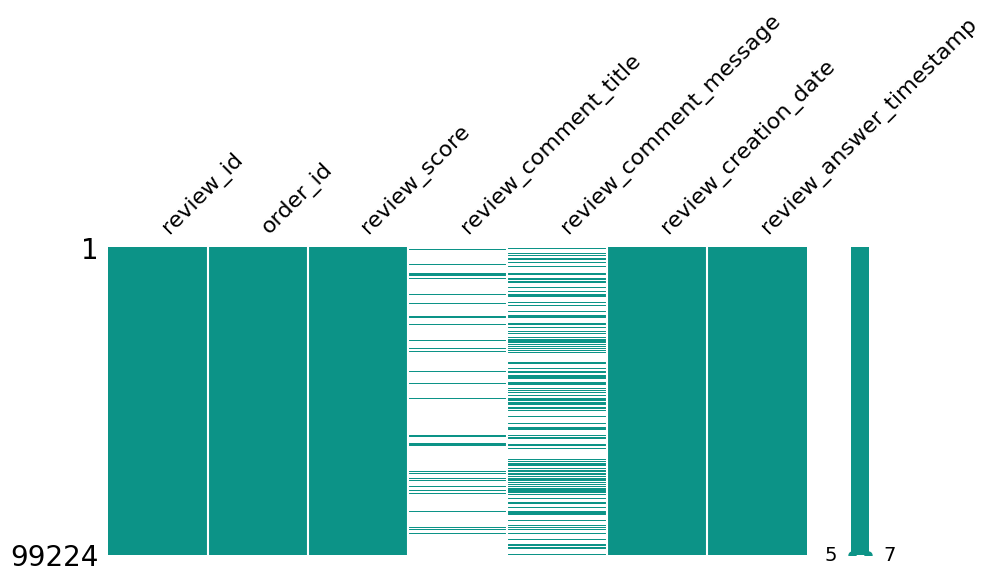

In [ ]:
miss_r = pd.DataFrame({
    "n_missing": reviews.isna().sum(),
    "pct_missing": (reviews.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
print(miss_r)
msno.matrix(reviews, figsize=(10, 4), color=(0.05, 0.58, 0.53))
plt.show()
# review_comment_title and review_comment_message: missing in most rows.
# review_comment_message is likely MNAR/MAR: people who feel strongly (often
# negative) leave a comment, so the gap depends on the sentiment itself.


### Solution · Practice 1, Part B

In [ ]:
neg = reviews["review_score"] <= 2
pos = reviews["review_score"] >= 4
rate_neg = reviews.loc[neg, "review_comment_message"].isna().mean()
rate_pos = reviews.loc[pos, "review_comment_message"].isna().mean()
print(f"comment missing rate, negative reviews: {rate_neg:.3f}")
print(f"comment missing rate, positive reviews: {rate_pos:.3f}")
# B2: the missingness depends on the score (an observed variable) and plausibly on
# the unobserved strength of feeling, so it is MAR at least, arguably MNAR. Either
# way, NOT MCAR: dropping these rows would bias the sentiment picture.


comment missing rate, negative reviews: 0.253
comment missing rate, positive reviews: 0.653


### Solution · Practice 1, Stretch

In [ ]:
reviews_s = reviews.copy()
reviews_s["comment_missing"] = reviews_s["review_comment_message"].isna().astype(int)
reviews_s["is_negative"] = (reviews_s["review_score"] <= 2).astype(int)
print(reviews_s[["comment_missing", "is_negative"]].corr().iloc[0, 1].round(3))
# A non-trivial correlation means the ABSENCE of a comment carries signal: the
# missingness indicator is itself a useful feature.


-0.282


### Solution · Practice 2, Part A

In [ ]:
num = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))])
ct = ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])
pipe = Pipeline([("pre", ct), ("model", LogisticRegression(max_iter=1000))])
print("baseline cv roc_auc:", cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean().round(4))


baseline cv roc_auc: 0.5571


### Solution · Practice 2, Part B

In [ ]:
num_ind = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler())])
ct_ind = ColumnTransformer([("num", num_ind, num_cols), ("cat", cat, cat_cols)])
pipe_ind = Pipeline([("pre", ct_ind), ("model", LogisticRegression(max_iter=1000))])
base = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()
withi = cross_val_score(pipe_ind, X, y, cv=5, scoring="roc_auc").mean()
print(f"without indicator: {base:.4f}")
print(f"with indicator   : {withi:.4f}")
print(f"gain: {withi - base:+.4f}  (if positive, the missingness carried signal)")


without indicator: 0.5571
with indicator   : 0.5567
gain: -0.0003  (if positive, the missingness carried signal)


### Solution · Practice 2, Stretch

In [ ]:
num_knn = Pipeline([("impute", KNNImputer(n_neighbors=5)), ("scale", StandardScaler())])
ct_knn = ColumnTransformer([("num", num_knn, num_cols), ("cat", cat, cat_cols)])
pipe_knn = Pipeline([("pre", ct_knn), ("model", LogisticRegression(max_iter=1000))])
print("KNN imputation cv roc_auc:", cross_val_score(pipe_knn, X, y, cv=5, scoring="roc_auc").mean().round(4))
# Usually within a few thousandths of median. The added cost rarely pays off here.


KNN imputation cv roc_auc: 0.5572


### Solution · Practice 3, Part A

In [ ]:
pay = payments.groupby("order_id")["payment_value"].sum().reset_index()
pv = pay["payment_value"]
q1, q3 = pv.quantile(0.25), pv.quantile(0.75); iqr = q3 - q1
iqr_out = ((pv < q1 - 1.5 * iqr) | (pv > q3 + 1.5 * iqr))
z_out = np.abs(stats.zscore(pv)) > 3
print(f"IQR: {iqr_out.sum()} | Z-score: {z_out.sum()} | agree: {(iqr_out.values & z_out).sum()}")
# Choice: clip at p99. Statistical: it caps extreme leverage without dropping rows.
# Business: large legitimate payments are real customers we do not want to erase.


IQR: 7866 | Z-score: 1724 | agree: 1724


### Solution · Practice 3, Part B and Stretch

In [ ]:
# Effect of clip vs log on the model, reusing make_pipe from the demo
for name, tf in [("raw", None), ("log1p", log_tf), ("clip p99", clip_tf)]:
    sc = cross_val_score(make_pipe(tf), X, y, cv=5, scoring="roc_auc").mean()
    print(f"{name:10s} cv roc_auc: {sc:.4f}")
# Whichever wins, the point is that the decision is measured, not assumed, and
# justified in business terms, not only statistical ones.


raw        cv roc_auc: 0.5571
log1p      cv roc_auc: 0.5562
clip p99   cv roc_auc: 0.5573
